# Pre-Act Agent-State Probing in a **Distilled** Student (Qwen3-32B → Qwen3-1.7B)

teacher 노트북(`agent_state_preact_probe_qwen3_32b.ipynb`)이 **Qwen3-32B** 에서 그린
*primary point(`pre_code`)의 layer별 PCA grid* 를, **32B 를 1.7B 에 distillation 한 student**
에서도 **동일한 방식**으로 재현합니다.

파이프라인:
1. **Distillation dataset 생성** — 32B teacher 의 ReAct 궤적(`logs/.../Qwen3-32B_*.jsonl`)을
   *thought–action* multi-turn 대화로 변환 (teacher 노트북과 **동일한 파싱/라벨링**).
   `user(task) → assistant(Thought+Code) → user(Observation) → assistant …`
2. **Distillation (SFT)** — `Qwen/Qwen3-1.7B` 를 TRL `SFTTrainer` + LoRA 로
   *completion-only* loss(assistant 토큰만) 학습. `exps_research/finetune_sft.py` 와 동일 설정.
3. **Probing & PCA** — distilled student 를 로드해 **teacher 와 동일한 표본**(같은 SEED 샘플링)에
   대해 3개 probe 지점을 한 forward 로 추출하고, `pre_code` 의 **layer별 PCA grid** 를 그립니다.

> probe 는 **teacher-forced**: teacher 가 쓴 동일한 `prefix+act` 텍스트를 student 에 통과시켜
> *student 내부 표현*만 비교합니다. 입력·라벨이 teacher 그림과 같아 **그림이 직접 비교 가능**합니다.

| 지점 | 위치 | 해석 |
|---|---|---|
| `pre_act`    | assistant 턴 **시작 직전** prefix 마지막 N토큰 | 추론 전 순수 예측 |
| `pre_code`   | Thought 끝 ~ ```py **코드 직전** | 추론 후 act 확정 (**primary**) |
| `during_act` | assistant 턴 전체 mean-pool | baseline |


## Section 1 · Setup & Config

In [2]:
import sys, os, json, ast, re, gc, warnings, logging
os.environ["CUDA_VISIBLE_DEVICES"] = "6"          # 1.7B 는 GPU 1장이면 충분
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

def _find_root() -> Path:
    p = Path(".").resolve()
    for _ in range(6):
        if (p / "logs" / "qa_results").exists():
            return p
        p = p.parent
    return Path("/workspace/Agent-Distillation")

ROOT = _find_root()
sys.path.append(str(ROOT / "exps_research"))      # train_utils 임포트용
print("Project root:", ROOT)

# ── teacher / student ────────────────────────────────────────────────────────
TEACHER_NAME  = "Qwen/Qwen3-32B"        # distillation dataset 을 만든 teacher
STUDENT_NAME  = "Qwen/Qwen3-1.7B"       # distillation 대상 student
DTYPE         = torch.bfloat16
DEVICE_MAP    = "auto"

# distillation(SFT) 산출물 위치
STUDENT_CKPT  = ROOT / "training_outputs" / "qwen3-1.7B" / "agent_distill_from_qwen3_32b"

# ── probe 설정 (teacher 노트북과 동일) ───────────────────────────────────────
INCLUDE_QA    = True
MAX_PER_STATE = 120
MAX_LEN       = 2048
SEED          = 42

N_LAST        = 8          # prefix 끝단 pooling 토큰 수
POOL          = "mean"     # "mean" | "last"
PROBE_POINTS  = ["pre_act", "pre_code", "during_act"]
PRIMARY_POINT = "pre_code" # PCA grid 기준 지점

TARGET_STATES = ["retrieve", "symbolic_math", "numeric_compute", "finalize", "compute", "inspect"]
# LAYERS 는 student 로드 후(Section 5) config 로부터 동적으로 설정

# ── distillation(SFT) 하이퍼파라미터 ─────────────────────────────────────────
DISTILL_EPOCHS    = 2
DISTILL_LR        = 2e-4
DISTILL_MAXLEN    = 4096
DISTILL_BS        = 1
DISTILL_GA        = 8
MAX_TRAIN_DIALOGS = None     # None = 전체. 빠른 테스트시 예: 200
FORCE_RETRAIN     = False    # True 면 체크포인트 있어도 재학습

OUT_DIR = ROOT / "outputs" / "agent_state_probe"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DISTILL_DATA_DIR = ROOT / "data" / "distill"
DISTILL_DATA_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

print("CUDA_VISIBLE_DEVICES:", os.environ["CUDA_VISIBLE_DEVICES"])
print("visible device count:", torch.cuda.device_count(), "| cuda:", torch.cuda.is_available())
print("probe points:", PROBE_POINTS, "| primary:", PRIMARY_POINT)

# ── 안전장치: env 적용/GPU 점유 확인 ──
if torch.cuda.device_count() != 1:
    print("⚠️ visible device count =", torch.cuda.device_count(),
          "→ CUDA_VISIBLE_DEVICES 미적용. 커널 Restart 후 이 셀을 먼저 실행하세요.")
else:
    free, total = torch.cuda.mem_get_info()
    print(f"bound GPU free/total: {free/1e9:.1f} / {total/1e9:.1f} GB")
    if free < 20e9:
        print("⚠️ 이 GPU가 이미 점유됨 → 빈 GPU(예: 3,7)로 바꾸고 커널 Restart 권장.")


Project root: /workspace/Agent-Distillation
CUDA_VISIBLE_DEVICES: 6
visible device count: 1 | cuda: True
probe points: ['pre_act', 'pre_code', 'during_act'] | primary: pre_code
bound GPU free/total: 47.3 / 47.6 GB


## Section 2 · 로그 파싱 + act → agent-state 라벨링

teacher 노트북과 **완전히 동일한** 파싱/라벨링/샘플링. 여기서 만든 표본(`samples`)은
(1) distillation dataset 의 원천이자 (2) probe 의 입력으로 그대로 재사용됩니다.
같은 `SEED` 라 teacher 그림과 **표본·라벨이 일치**합니다.

In [3]:
TEACHER_FILES = [
    ROOT / "logs/qa_results/vllm/Qwen_Qwen3-32B/math_1000_20250414_train/Qwen3-32B_temp=0.0_seed=42_type=agent_steps=5.jsonl",
    ROOT / "logs/qa_results/vllm/Qwen_Qwen3-32B/math_medium_1000_20250430_train/Qwen3-32B_temp=0.0_seed=42_type=agent_steps=5.jsonl",
]
QA_FILES = [
    ROOT / "logs/qa_results/vllm/Qwen_Qwen2.5-1.5B-Instruct/hotpotqa_500_20250422_test/Qwen2.5-1.5B-Instruct_temp=0.0_seed=42_type=agent_steps=5.jsonl",
    ROOT / "logs/qa_results/vllm/Qwen_Qwen2.5-1.5B-Instruct/musique_500_20250504_test/Qwen2.5-1.5B-Instruct_temp=0.0_seed=42_type=agent_steps=5.jsonl",
]

def load_jsonl(f):
    rows = []
    for line in open(f):
        line = line.strip()
        if not line: continue
        try: d = json.loads(line)
        except Exception: continue
        if isinstance(d, str):
            try: d = ast.literal_eval(d)
            except Exception:
                try: d = json.loads(d)
                except Exception: continue
        if isinstance(d, dict): rows.append(d)
    return rows

def get_messages(d):
    ld = d.get("log_data")
    if isinstance(ld, str):
        try: ld = ast.literal_eval(ld)
        except Exception:
            try: ld = json.loads(ld)
            except Exception: return []
    return ld.get("messages", []) if isinstance(ld, dict) else []

def role_of(m): return str(m.get("role")).split(".")[-1].lower().replace("-", "_")
def text_of(m):
    c = m.get("content")
    if isinstance(c, list): return " ".join(x.get("text","") for x in c if isinstance(x,dict))
    return str(c)

def code_of(t):
    m = re.search(r"```py(.*?)```", t, re.S) or re.search(r"Code:\s*(.*)$", t, re.S)
    return m.group(1) if m else t

def label_state(code):
    c = code.lower()
    if re.search(r"\b(retriever|web_search|wiki|document_qa|image_search|visit_webpage)\b|\bsearch\(", c): return "retrieve"
    if re.search(r"sympy|symbols\(|\bsolve\(|\bEq\(|simplify|integrate|\bdiff\(|expand\(|factor\(", code): return "symbolic_math"
    if re.search(r"\bnp\.|numpy|\bmath\.|factorial|comb\(|sqrt\(|\.evalf", code): return "numeric_compute"
    flat = re.sub(r"\s", "", code)
    if re.match(r"^final_answer\(.*\)$", flat) or (re.search(r"final_answer\(", c) and not re.search(r"\bfor\b|\bwhile\b|\bdef\b|=", code)): return "finalize"
    if re.search(r"\bfor\b|\bwhile\b|\bdef\b|range\(|append\(", code): return "compute"
    if re.search(r"\bprint\(", c): return "inspect"
    return "other"

def extract_acts(files, domain):
    out = []
    for f in files:
        if not Path(f).exists():
            print("  [skip] not found:", f); continue
        for d in load_jsonl(f):
            prefix = ""; step = 0
            for m in get_messages(d):
                if not isinstance(m, dict): continue
                r = role_of(m)
                if r == "tool_call": continue
                t = text_of(m)
                if r == "assistant":
                    out.append({"prefix": prefix, "act": t, "state": label_state(code_of(t)),
                                "domain": domain, "step_idx": step})
                    step += 1
                    prefix = prefix + "\n" + t
                else:
                    prefix = prefix + ("\n" + t if prefix else t)
    return out

acts = extract_acts(TEACHER_FILES, "math")
if INCLUDE_QA: acts += extract_acts(QA_FILES, "qa")
print("총 act 표본:", len(acts))
print("state 분포 :", dict(Counter(a["state"] for a in acts).most_common()))

총 act 표본: 7180
state 분포 : {'retrieve': 4382, 'symbolic_math': 798, 'compute': 628, 'other': 407, 'numeric_compute': 377, 'finalize': 330, 'inspect': 258}


In [4]:
by_state = defaultdict(list)
for a in acts:
    if a["state"] in TARGET_STATES:
        by_state[a["state"]].append(a)

samples = []
for st in TARGET_STATES:
    pool = by_state.get(st, [])
    if not pool:
        print(f"  [warn] state '{st}' 표본 없음 → 제외"); continue
    idx = rng.permutation(len(pool))[:MAX_PER_STATE]
    samples += [pool[i] for i in idx]
rng.shuffle(samples)
STATES = [s for s in TARGET_STATES if by_state.get(s)]
print("최종 표본:", len(samples))
print("state별 :", dict(Counter(s["state"] for s in samples).most_common()))
print("step별 :", dict(Counter(s["step_idx"] for s in samples).most_common()))

최종 표본: 720
state별 : {'numeric_compute': 120, 'inspect': 120, 'retrieve': 120, 'finalize': 120, 'compute': 120, 'symbolic_math': 120}
step별 : {0: 269, 1: 190, 2: 113, 3: 75, 4: 73}


## Section 3 · Distillation dataset 생성 (ReAct thought–action)

32B teacher 의 각 궤적을 multi-turn 대화로 변환합니다. Section 2 와 **동일한 파서**
(`load_jsonl`/`get_messages`/`role_of`/`text_of`)를 재사용하므로 별도 의존성이 없습니다.

- `tool_call` 메시지는 assistant 코드와 중복이라 제거
- `tool_response`(Observation) → `user`
- `system / user / assistant(Thought+Code)` 는 그대로 유지

→ student 는 teacher 의 *thought–action* 시퀀스를 모방하도록 학습됩니다 (ReAct distillation).

In [5]:
from datasets import Dataset

def build_sft_dialogues(files):
    dialogs = []
    for f in files:
        if not Path(f).exists():
            print("  [skip] not found:", f); continue
        for d in load_jsonl(f):
            msgs = get_messages(d)
            if not msgs:
                continue
            conv = []
            for m in msgs:
                if not isinstance(m, dict):
                    continue
                r = role_of(m)
                if r == "tool_call":              # assistant code 와 중복
                    continue
                role = "user" if r == "tool_response" else r
                conv.append({"role": role, "content": text_of(m)})
            if conv and conv[0]["role"] == "system" and any(c["role"] == "assistant" for c in conv):
                dialogs.append({"messages": conv})
    return dialogs

# distillation 은 32B teacher 궤적만 사용 (TEACHER_FILES)
sft_dialogs = build_sft_dialogues(TEACHER_FILES)
if MAX_TRAIN_DIALOGS:
    sft_dialogs = sft_dialogs[:MAX_TRAIN_DIALOGS]

SFT_JSONL = DISTILL_DATA_DIR / "qwen3_32b_teacher_agent_sft.jsonl"
with open(SFT_JSONL, "w") as f:
    for r in sft_dialogs:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

train_dataset = Dataset.from_list(sft_dialogs)
n_asst = sum(sum(1 for m in d["messages"] if m["role"] == "assistant") for d in sft_dialogs)
print("distillation 대화 수:", len(train_dataset), "| assistant(act) 턴:", n_asst)
print("saved:", SFT_JSONL)

# ReAct thought-action 구조 미리보기
ex = train_dataset[0]["messages"]
print("\nroles:", [m["role"] for m in ex])
for m in ex:
    if m["role"] == "assistant":
        print("\n--- 첫 assistant(Thought+Code) ---\n" + m["content"][:400]); break


distillation 대화 수: 1341 | assistant(act) 턴: 2391
saved: /workspace/Agent-Distillation/data/distill/qwen3_32b_teacher_agent_sft.jsonl

roles: ['system', 'user', 'assistant', 'user']

--- 첫 assistant(Thought+Code) ---
Thought: For a quadratic equation $x^2 + bx + 16$ to have at least one real root, its discriminant must be non-negative. The discriminant of a quadratic equation $ax^2 + bx + c$ is given by $\Delta = b^2 - 4ac$. In this case, $a = 1$, $b = b$, and $c = 16$. So, the condition becomes $b^2 - 4(1)(16) \geq 0$. I will solve this inequality to find the possible values of $b$.

Code:
```py
from sympy im


## Section 4 · Qwen3-1.7B 에 distillation (TRL SFT + LoRA)

`exps_research/finetune_sft.py` 와 **동일한 설정**으로 학습합니다:
- LoRA(`r=64, α=128, all-linear`), bf16
- `DataCollatorForCompletionOnlyLMMultiTurn` 로 **assistant 토큰에만 loss** (multi-turn)
- response/instruction template: `"<|im_start|>assistant"` / `"<|im_start|>user"`

체크포인트가 이미 있으면 학습을 건너뜁니다(`FORCE_RETRAIN=True` 로 강제 재학습).

> 멀티-GPU 로 돌리려면 동일 데이터로 레포의 스크립트도 사용할 수 있습니다(파싱은 본 노트북이 처리):
> `Dataset` 을 jsonl 로 저장해 두었으니 단일 GPU in-notebook 학습이 가장 간단합니다.

In [6]:
adapter_ready = (STUDENT_CKPT / "adapter_config.json").exists() or (STUDENT_CKPT / "config.json").exists()
if adapter_ready and not FORCE_RETRAIN:
    print("이미 distilled checkpoint 존재 → 학습 건너뜀:", STUDENT_CKPT)
else:
    from transformers import AutoTokenizer
    from peft import LoraConfig
    from trl import SFTTrainer, SFTConfig
    from train_utils.utils import DataCollatorForCompletionOnlyLMMultiTurn

    tok = AutoTokenizer.from_pretrained(
        STUDENT_NAME, pad_token="<|endoftext|>", padding_side="left", add_eos_token=True)

    peft_config = LoraConfig(
        r=64, lora_alpha=128, target_modules="all-linear",
        lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")

    collator = DataCollatorForCompletionOnlyLMMultiTurn(
        "<|im_start|>assistant", instruction_template="<|im_start|>user", tokenizer=tok)

    train_args = SFTConfig(
        per_device_train_batch_size=DISTILL_BS,
        gradient_accumulation_steps=DISTILL_GA,
        max_length=DISTILL_MAXLEN,
        bf16=True,
        num_train_epochs=DISTILL_EPOCHS,
        learning_rate=DISTILL_LR,
        logging_steps=10,
        save_strategy="no",
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        report_to="none",
        output_dir=str(STUDENT_CKPT),
    )

    trainer = SFTTrainer(
        STUDENT_NAME, args=train_args, peft_config=peft_config,
        data_collator=collator, train_dataset=train_dataset)
    trainer.train()
    trainer.save_model(str(STUDENT_CKPT))
    print("saved distilled adapter →", STUDENT_CKPT)

    del trainer
    gc.collect(); torch.cuda.empty_cache()


Truncating train dataset: 100%|██████████| 1341/1341 [00:00<00:00, 52960.48 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,0.306838
20,0.233847
30,0.243302
40,0.244517
50,0.227050
60,0.235077
70,0.220538
80,0.220954
90,0.218291
100,0.219209


saved distilled adapter → /workspace/Agent-Distillation/training_outputs/qwen3-1.7B/agent_distill_from_qwen3_32b


## Section 5 · Distilled student 로드 + LAYERS 설정

LoRA 어댑터면 base 에 병합(`merge_and_unload`)해 probe 합니다. distilled 체크포인트가 없으면
base `Qwen3-1.7B` 로 진행(경고) — 먼저 Section 4 를 실행하는 걸 권장합니다.
`LAYERS` 는 1.7B config(`num_hidden_layers`)로부터 동적으로 설정합니다.

In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

has_adapter = (STUDENT_CKPT / "adapter_config.json").exists()
has_full    = (STUDENT_CKPT / "config.json").exists() and not has_adapter
USE_DISTILLED = has_adapter or has_full
print("Loading student:", STUDENT_NAME, "| distilled:", USE_DISTILLED, "| adapter:", has_adapter)

tokenizer = AutoTokenizer.from_pretrained(STUDENT_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if has_full:
    model = AutoModelForCausalLM.from_pretrained(
        str(STUDENT_CKPT), torch_dtype=DTYPE, device_map=DEVICE_MAP,
        trust_remote_code=True, output_hidden_states=True)
else:
    model = AutoModelForCausalLM.from_pretrained(
        STUDENT_NAME, torch_dtype=DTYPE, device_map=DEVICE_MAP,
        trust_remote_code=True, output_hidden_states=True)
    if has_adapter:
        model = PeftModel.from_pretrained(model, str(STUDENT_CKPT))
        model = model.merge_and_unload()          # probe 위해 LoRA 병합
        print("LoRA adapter merged from", STUDENT_CKPT)
    else:
        print("\u26a0\ufe0f  distilled checkpoint 없음 → base Qwen3-1.7B 로 진행 (Section 4 먼저 권장)")

model.eval()
EMB_DEVICE = model.get_input_embeddings().weight.device
n_hl = model.config.num_hidden_layers
LAYERS = list(range(0, n_hl + 1))                 # hidden_states: 0(emb) .. n_hl
print(f"layers={n_hl}  hidden={model.config.hidden_size}  emb_device={EMB_DEVICE}")
print("LAYERS:", LAYERS[:4], "...", LAYERS[-3:], f"({len(LAYERS)} pts)")


Loading student: Qwen/Qwen3-1.7B | distilled: True | adapter: True


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 311/311 [00:00<00:00, 663.04it/s]


LoRA adapter merged from /workspace/Agent-Distillation/training_outputs/qwen3-1.7B/agent_distill_from_qwen3_32b
layers=28  hidden=2048  emb_device=cuda:0
LAYERS: [0, 1, 2, 3] ... [26, 27, 28] (29 pts)


## Section 6 · 3개 probe 지점 표현 추출 (한 forward · teacher-forced)

teacher 노트북 Section 4 와 동일한 추출 로직. 단, forward 모델만 **distilled student** 로 교체.
결과는 student 전용 캐시(`student_preact_reps_*.npz`)에 저장됩니다.

In [8]:
CACHE = OUT_DIR / f"student_preact_reps_{'with' if INCLUDE_QA else 'no'}qa_n{MAX_PER_STATE}_L{N_LAST}_{POOL}.npz"

def _regions(prefix, act):
    pre  = tokenizer(prefix, add_special_tokens=True).input_ids
    thought = act[:act.index("```py")] if "```py" in act else act
    mid  = tokenizer(prefix + "\n" + thought, add_special_tokens=True).input_ids
    full = tokenizer(prefix + "\n" + act, add_special_tokens=True).input_ids
    n_pre, n_mid, n_full = len(pre), len(mid), len(full)
    drop = max(0, n_full - MAX_LEN)
    if drop: full = full[-MAX_LEN:]
    sh = lambda i: max(0, i - drop)
    n_pre, n_mid, n_full = sh(n_pre), sh(n_mid), len(full)
    n_mid = max(n_mid, n_pre)
    regs = {}
    a = max(0, n_pre - N_LAST);  regs["pre_act"]  = (a, max(a + 1, n_pre))
    a = max(0, n_mid - N_LAST);  regs["pre_code"] = (a, max(a + 1, n_mid))
    a = n_pre; b = n_full
    if b <= a: a = max(0, n_full - 1); b = n_full
    regs["during_act"] = (a, b)
    return full, regs

@torch.no_grad()
def rep_of(prefix, act):
    full, regs = _regions(prefix, act)
    ids = torch.tensor([full], device=EMB_DEVICE)
    hs = model(input_ids=ids, output_hidden_states=True, use_cache=False).hidden_states
    out = {}
    for pt in PROBE_POINTS:
        a, b = regs[pt]
        for L in LAYERS:
            span = hs[L][0, a:b, :]
            out[(pt, L)] = (span[-1] if POOL == "last" else span.mean(0)).float().cpu().numpy()
    return out

if CACHE.exists():
    data = np.load(CACHE, allow_pickle=True)
    X = {pt: {L: data[f"X_{pt}_{L}"] for L in LAYERS} for pt in PROBE_POINTS}
    y = data["y"]; dom = data["dom"]; step = data["step"]
    print("loaded cache:", CACHE.name)
else:
    try: from tqdm.auto import tqdm
    except Exception:
        def tqdm(x, **k): return x
    buf = {(pt, L): [] for pt in PROBE_POINTS for L in LAYERS}
    y, dom, step = [], [], []
    for s in tqdm(samples, desc="extract"):
        v = rep_of(s["prefix"], s["act"])
        for k in buf: buf[k].append(v[k])
        y.append(s["state"]); dom.append(s["domain"]); step.append(s["step_idx"])
    X = {pt: {L: np.stack(buf[(pt, L)]) for L in LAYERS} for pt in PROBE_POINTS}
    y = np.array(y); dom = np.array(dom); step = np.array(step)
    np.savez_compressed(CACHE, y=y, dom=dom, step=step,
                        **{f"X_{pt}_{L}": X[pt][L] for pt in PROBE_POINTS for L in LAYERS})
    print("saved cache:", CACHE.name)
print("표본:", len(y), "| dim:", X[PROBE_POINTS[0]][LAYERS[0]].shape[1])

extract: 100%|██████████| 720/720 [01:40<00:00,  7.19it/s]


saved cache: student_preact_reps_withqa_n120_L8_mean.npz
표본: 720 | dim: 2048


## Section 7 · PCA 시각화 — **primary point 의 layer별 PCA grid**

teacher 그림과 **동일한 방식**. 먼저 세 probe 지점을 같은 layer 에서 비교하고,
이어서 **`pre_code` 의 layer별 PCA grid**(요청한 그림)를 distilled 1.7B 에 대해 그립니다.

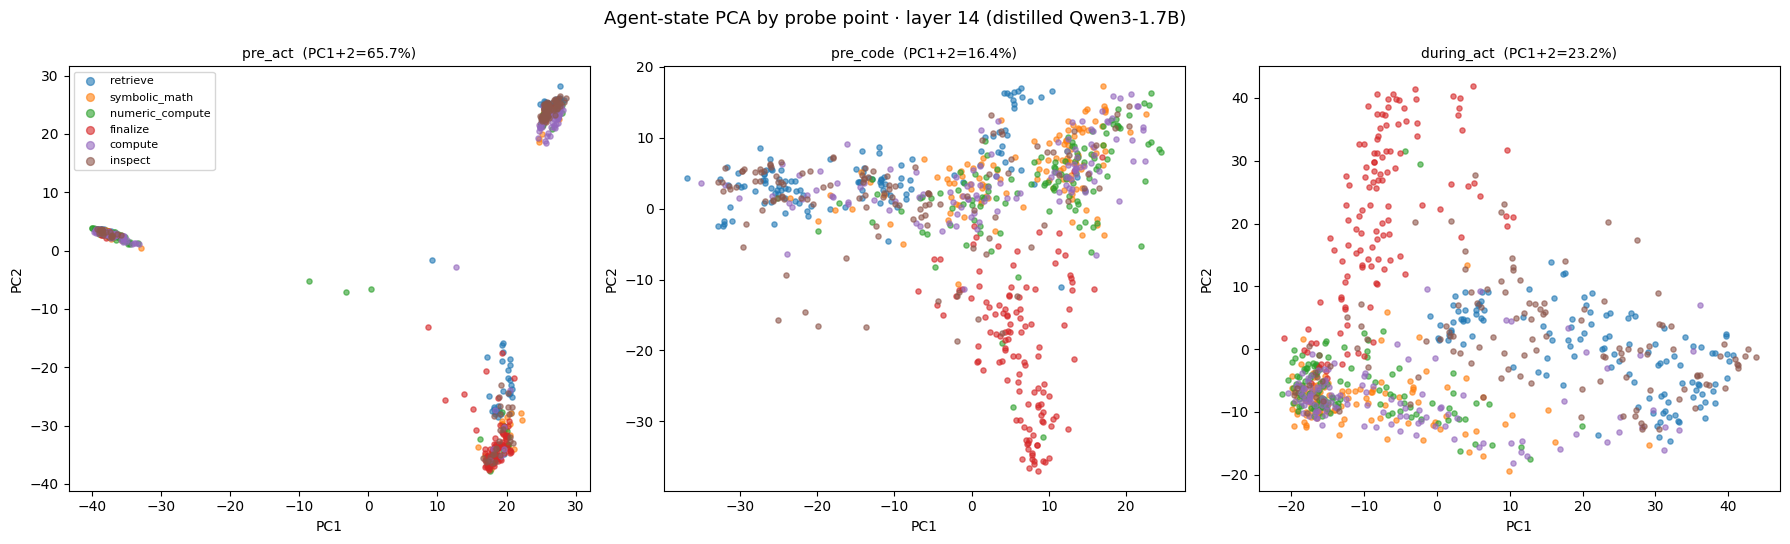

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
CMAP = {s: c for s, c in zip(STATES, matplotlib.cm.tab10.colors)}

def pca_ax(ax, mat, title):
    Z = StandardScaler().fit_transform(mat)
    p = PCA(n_components=2, random_state=SEED).fit(Z); P = p.transform(Z)
    for s in STATES:
        m = (y == s)
        ax.scatter(P[m,0], P[m,1], s=14, alpha=0.6, color=CMAP[s], label=s)
    ax.set_title(f"{title}  (PC1+2={p.explained_variance_ratio_.sum()*100:.1f}%)", fontsize=10)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

L_SHOW = LAYERS[len(LAYERS)//2]
fig, axes = plt.subplots(1, len(PROBE_POINTS), figsize=(6*len(PROBE_POINTS), 5.5))
for ax, pt in zip(np.atleast_1d(axes), PROBE_POINTS):
    pca_ax(ax, X[pt][L_SHOW], pt)
np.atleast_1d(axes)[0].legend(markerscale=1.5, fontsize=8, loc="best")
plt.suptitle(f"Agent-state PCA by probe point · layer {L_SHOW} (distilled Qwen3-1.7B)", fontsize=13)
plt.tight_layout(); plt.show()

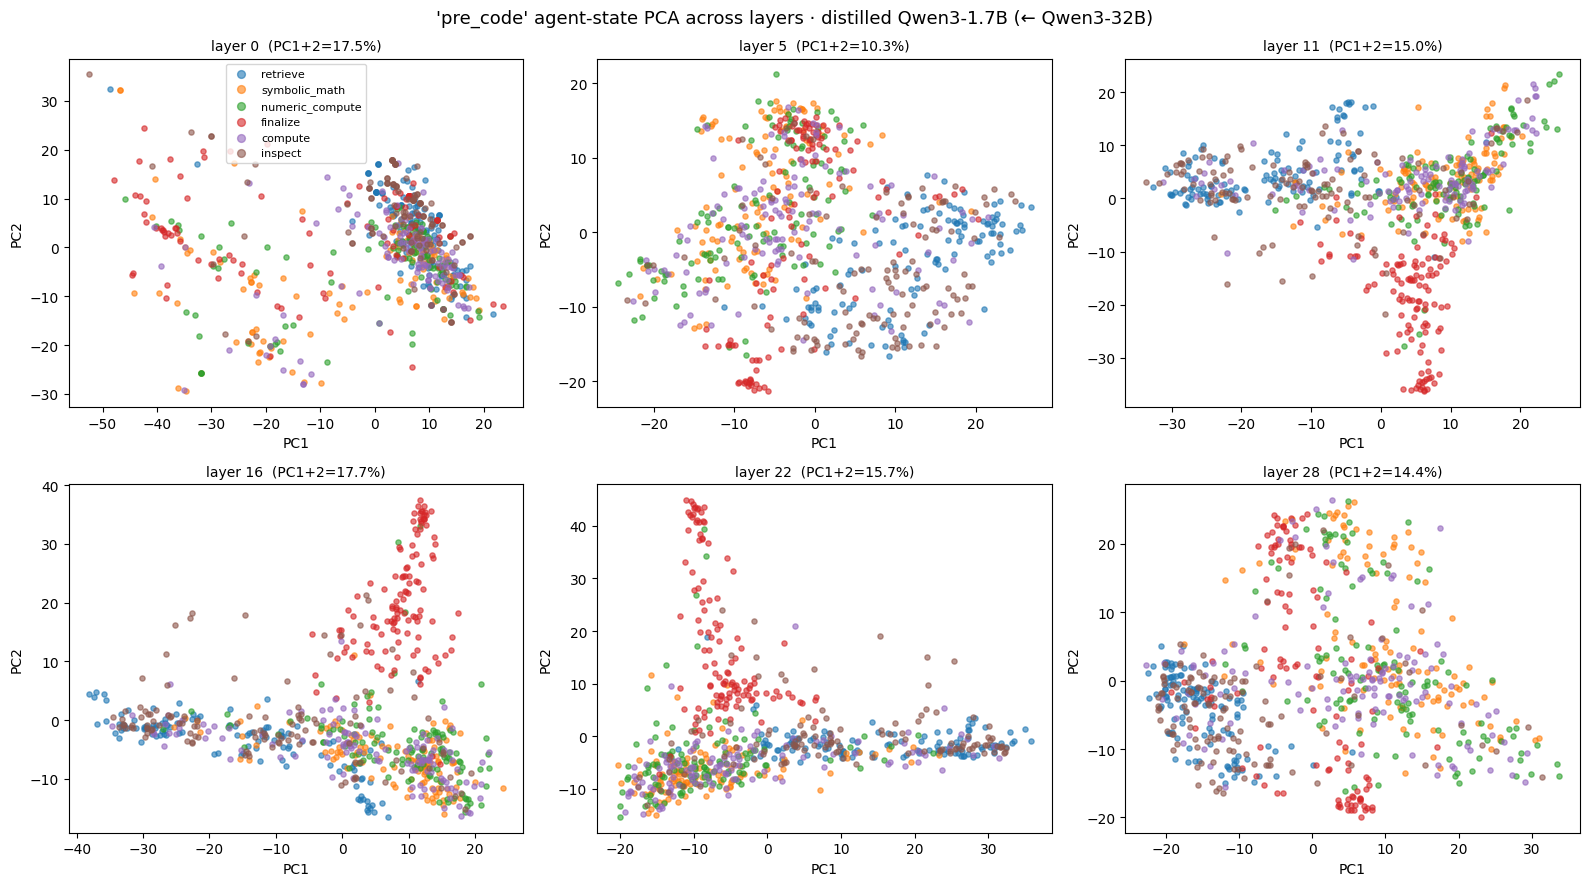

In [10]:
# PRIMARY_POINT 의 layer별 PCA grid
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
grid = [LAYERS[i] for i in np.linspace(0, len(LAYERS)-1, 6).astype(int)]
for ax, L in zip(axes.flat, grid):
    pca_ax(ax, X[PRIMARY_POINT][L], f"layer {L}")
axes.flat[0].legend(markerscale=1.5, fontsize=8, loc="best")
plt.suptitle(f"'{PRIMARY_POINT}' agent-state PCA across layers · distilled Qwen3-1.7B (\u2190 Qwen3-32B)", fontsize=13)
plt.tight_layout(); plt.show()

## Section 8 · Linear probe — "student 도 act 전에 state 를 아는가"

teacher 와 동일한 layer별 LogisticRegression 정확도/혼동행렬. distilled student 가
*act 를 쓰기 전*(`pre_act`/`pre_code`)에 이미 agent-state 를 선형 디코딩 가능한지 확인합니다.

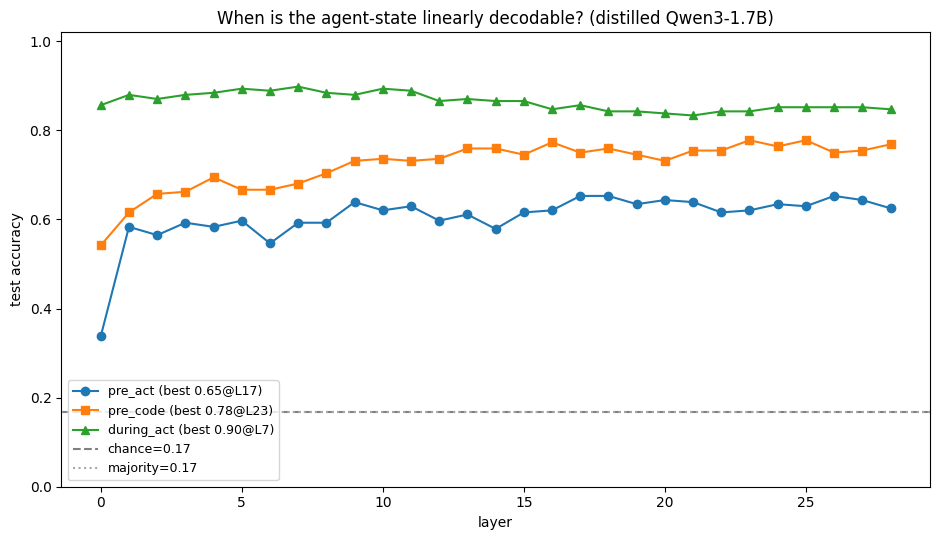

pre_act     best acc = 0.653  @ layer 17
pre_code    best acc = 0.778  @ layer 23
during_act  best acc = 0.898  @ layer 7


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline

idx = np.arange(len(y))
tr, te = train_test_split(idx, test_size=0.3, random_state=SEED, stratify=y)

def probe(mat):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0))
    clf.fit(mat[tr], y[tr]); pred = clf.predict(mat[te])
    return accuracy_score(y[te], pred), f1_score(y[te], pred, average="macro"), clf, pred

curves = {pt: [probe(X[pt][L])[0] for L in LAYERS] for pt in PROBE_POINTS}
chance = 1/len(STATES)
maj    = Counter(y[te]).most_common(1)[0][1]/len(te)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
mk = {"pre_act":"-o", "pre_code":"-s", "during_act":"-^"}
for pt in PROBE_POINTS:
    best = max(curves[pt]); bL = LAYERS[int(np.argmax(curves[pt]))]
    ax.plot(LAYERS, curves[pt], mk.get(pt,"-o"), label=f"{pt} (best {best:.2f}@L{bL})")
ax.axhline(chance, ls="--", c="gray", label=f"chance={chance:.2f}")
ax.axhline(maj,    ls=":",  c="darkgray", label=f"majority={maj:.2f}")
ax.set_xlabel("layer"); ax.set_ylabel("test accuracy"); ax.set_ylim(0,1.02)
ax.set_title("When is the agent-state linearly decodable? (distilled Qwen3-1.7B)")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

for pt in PROBE_POINTS:
    print(f"{pt:11s} best acc = {max(curves[pt]):.3f}  @ layer {LAYERS[int(np.argmax(curves[pt]))]}")

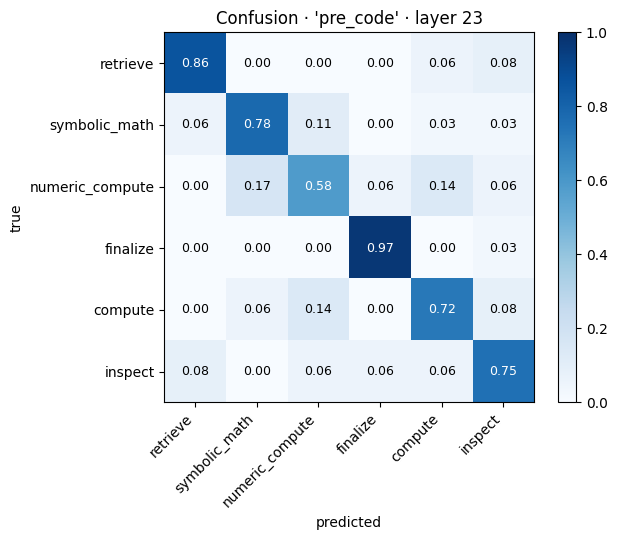

                 precision    recall  f1-score   support

       retrieve      0.861     0.861     0.861        36
  symbolic_math      0.778     0.778     0.778        36
numeric_compute      0.656     0.583     0.618        36
       finalize      0.897     0.972     0.933        36
        compute      0.722     0.722     0.722        36
        inspect      0.730     0.750     0.740        36

       accuracy                          0.778       216
      macro avg      0.774     0.778     0.775       216
   weighted avg      0.774     0.778     0.775       216



In [13]:
# PRIMARY_POINT 최적 layer confusion matrix + 리포트
bestL = LAYERS[int(np.argmax(curves[PRIMARY_POINT]))]
_, _, clf, pred = probe(X[PRIMARY_POINT][bestL])
cm = confusion_matrix(y[te], pred, labels=STATES)
cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(STATES))); ax.set_xticklabels(STATES, rotation=45, ha="right")
ax.set_yticks(range(len(STATES))); ax.set_yticklabels(STATES)
for i in range(len(STATES)):
    for j in range(len(STATES)):
        ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                color="white" if cmn[i,j]>0.5 else "black", fontsize=9)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Confusion · '{PRIMARY_POINT}' · layer {bestL}")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()
print(classification_report(y[te], pred, labels=STATES, digits=3))

## Section 9 · 메모

- **teacher 와 같은 표본·라벨**(SEED 동일) 위에서 그렸으므로, 32B 노트북의 같은 그림과
  **나란히 비교** 가능합니다. distilled 1.7B 의 군집이 teacher 만큼 갈라지는지가 핵심.
- `pre_act`/`pre_code` 정확도가 chance 를 크게 넘으면 → distillation 으로 student 도
  *act 생성 전부터* agent-state 를 표상하도록 학습됐다는 근거.
- 조정: `DISTILL_EPOCHS`, `MAX_TRAIN_DIALOGS`(빠른 시험), `N_LAST`, `POOL`, `PRIMARY_POINT`.
- distilled 체크포인트: `training_outputs/qwen3-1.7B/agent_distill_from_qwen3_32b`.

In [ ]:
del model
gc.collect(); torch.cuda.empty_cache()
print("freed.")
